In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import kktk

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

/rfs/project/rfs-iCNyzSAaucw/kk837/github/kktk/kktk/plotting.py:21: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [2]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [3]:
sc.settings.set_figure_params(dpi=80)

# Function

In [4]:
# https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_short_demo.html
def select_slide(adata, s, s_col='sample'):
    r""" This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param s_col: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

# Variables

In [6]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'
celltype = 'LymphoidCells'

In [7]:
# figdir = '/nfs/team205/heart/fetal_ms_figures/raw_plots_kk/Aug2024'
# table_dir = '/nfs/team205/heart/fetal_ms_figures/tables/Aug2024'

In [8]:
!ls -ls {data_object_dir}

total 2355880
233856 -rwxrwx---+ 1 kk837 kk837  495041445 Jan 28 08:54 b2c_cells_AtrialCardiomyocytes_lognorm.h5ad
 46424 -rwxrwx---+ 1 kk837 kk837   79748134 Jan 29 06:55 b2c_cells_EndothelialCells_lognorm.h5ad
 27984 -rwxrwx---+ 1 kk837 kk837   58503701 Jan  2 14:57 b2c_cells_EndothelialCells_raw.h5ad
 32232 -rwxrwx---+ 1 kk837 kk837   54299797 Feb  2 09:52 b2c_cells_EpicardialCells_lognorm.h5ad
 22120 -rwxrwx---+ 1 kk837 kk837   43772600 Jan  2 14:57 b2c_cells_EpicardialCells_raw.h5ad
 17456 -rwxrwx---+ 1 kk837 kk837   33218222 Jan  2 14:57 b2c_cells_LymphoidCells_raw.h5ad
324488 -rwxrwx---+ 1 kk837 kk837  697382266 Jan 29 04:26 b2c_cells_MesenchymalCells_lognorm.h5ad
281688 -rwxrwx---+ 1 kk837 kk837  658626360 Jan  2 14:57 b2c_cells_MesenchymalCells_raw.h5ad
 33048 -rwxrwx---+ 1 kk837 kk837   54512113 Jan 29 00:36 b2c_cells_MyeloidCells_lognorm.h5ad
 19560 -rwxrwx---+ 1 kk837 kk837   38611189 Jan  2 14:57 b2c_cells_MyeloidCells_raw.h5ad
 43024 -rwxrwx---+ 1 kk837 kk837   73958670 J

# Read in data

In [9]:
# read in
adata = sc.read_h5ad(f'{data_object_dir}/b2c_cells_{celltype}_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 2289 × 18077
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_tacco_ref-hd-scn_colors', 'donor_colors', 'library_colors', 'neighbors', 'umap'

# Log-normalisation

In [10]:
sc.pp.filter_genes(adata, min_cells=3)
print(adata.shape)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print(adata.X.data[:5])

(2289, 12239)
[2.02537432 2.02537432 2.02537432 2.02537432 2.02537432]


# Read in scVI-latent space and clustering results

In [11]:
adata_latent = sc.read_h5ad(f'{data_object_dir}/scVI/latent_variables/b2c_cells_{celltype}_correcting-donor_n-layers-3.h5ad')
adata_latent

AnnData object with n_obs × n_vars = 2289 × 50
    obs: 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0'
    uns: 'neighbors', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [12]:
adata.obsm['X_scVI'] = adata_latent[adata.obs_names,:].X.copy()
adata.obsm['X_umap'] = adata_latent[adata.obs_names,:].obsm['X_umap'].copy()
adata.obs[adata_latent.obs.columns] = adata_latent[adata.obs_names,:].obs.copy()

In [13]:
adata

AnnData object with n_obs × n_vars = 2289 × 12239
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_c

In [14]:
adata.obs['library'].value_counts()

library
CellTalkHHD_Human_13_BRC2757-2758-7    1803
HEA_FOET14880396                        486
Name: count, dtype: int64

# Plotting

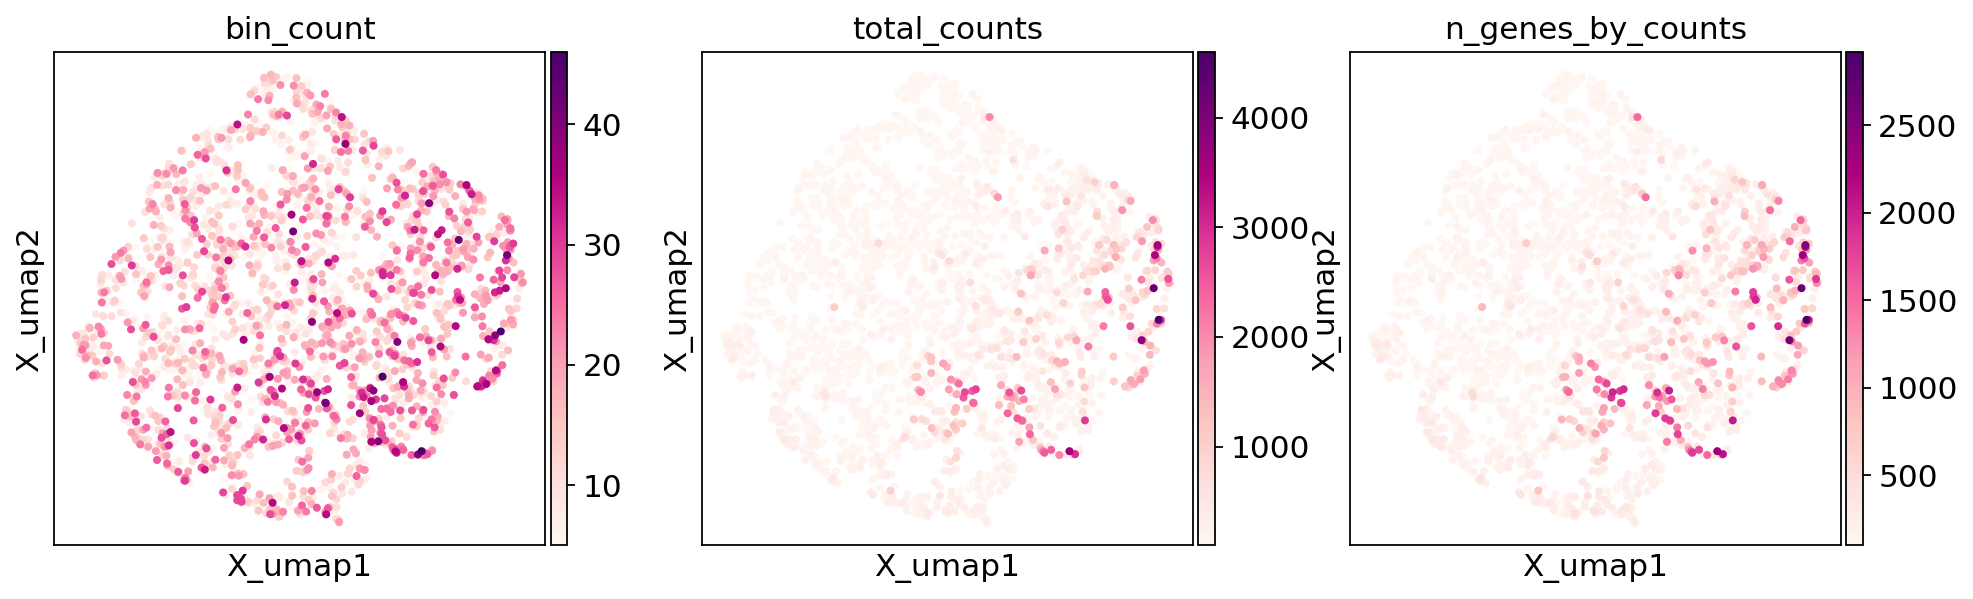

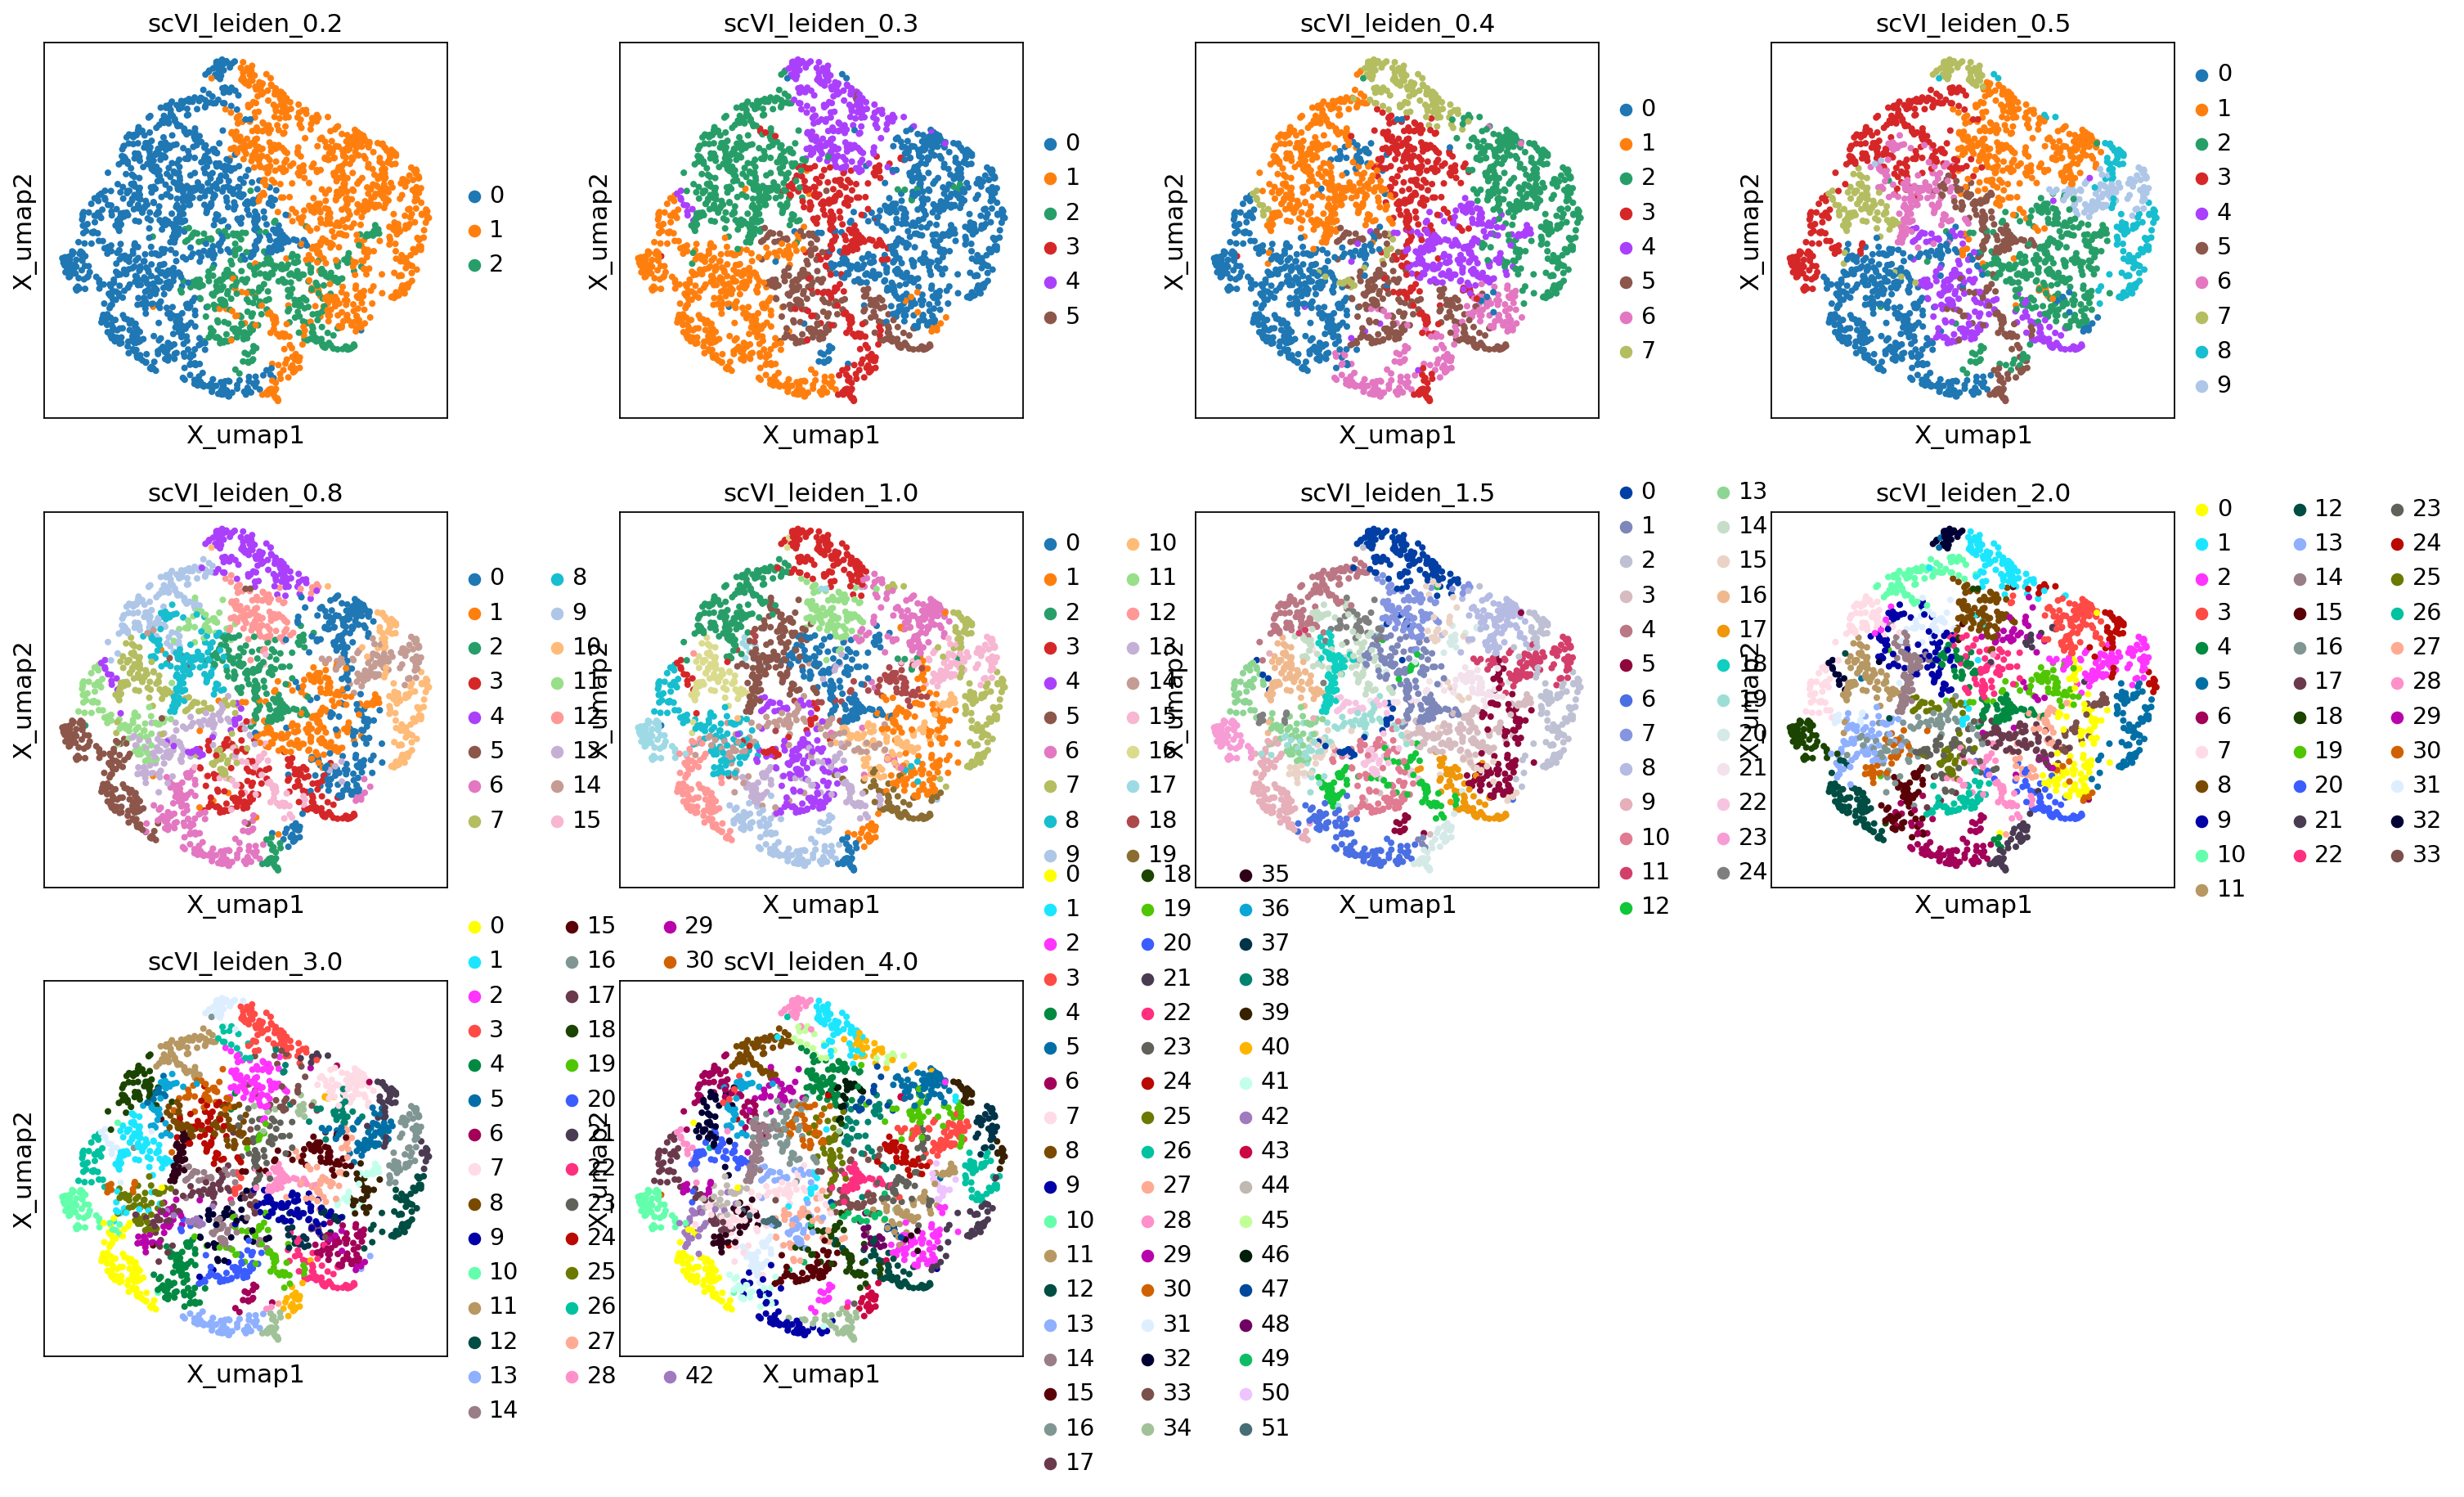

In [15]:
# visualisation with umap
sc.pl.embedding(adata,basis='X_umap',
                color=['bin_count','total_counts','n_genes_by_counts'],
                wspace=0.2,cmap='RdPu',vmax='p100',ncols=5)
# leiden clustering
resolutions_list = [0.2,0.3,0.4,0.5,0.8,1.0,1.5,2.0,3.0,4.0]
sc.pl.embedding(adata,basis='X_umap',
                color=[f'scVI_leiden_{str(resolution)}' for resolution in resolutions_list],
                wspace=0.3)

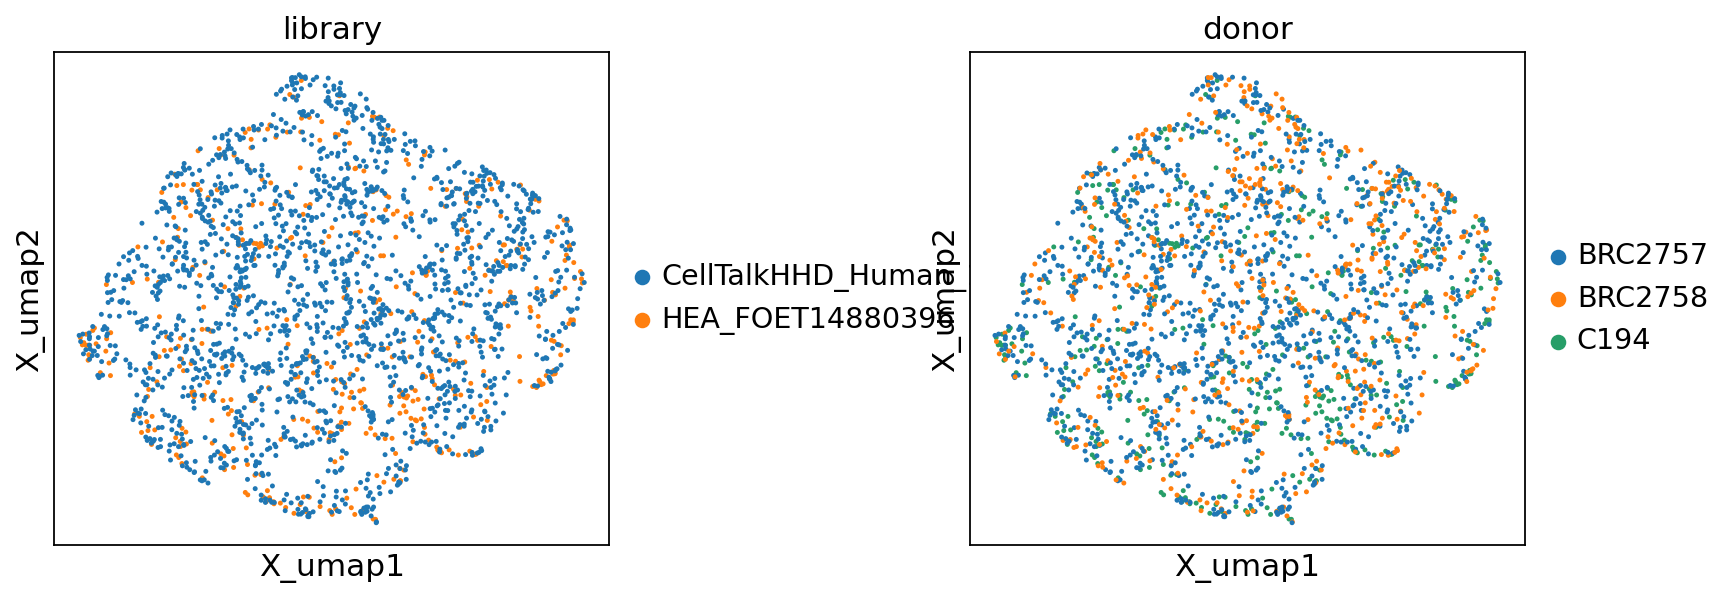

In [16]:
sc.pl.embedding(adata,basis='X_umap',
                color=['library','donor'], 
           size=20, wspace=0.5, ncols=6)

In [18]:
!ls /rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/VisiumHD/re-seq_mpp0p3

archive
bsub
CCSaxis_no1_annotate-landmark.ipynb
CCSaxis_no2_calculate_axis.ipynb
CCSaxis_no3_genes.ipynb
CCSaxis_no4_neighbouring-cells.ipynb
CCSaxis_no4_neighbouring-ligands.ipynb
CCSaxis_no5_HD_to_single-cell.ipynb
cellcharter
celltype_plot_finegrain.ipynb
celltype_plot_midgrain.ipynb
celltypist
cpdb
feature-marker_selection.ipynb
head_neibouring_ligands.csv
loupe_annotation
no10_plotting.ipynb
no1_bin2cell_HE-nucleus-segmentation.ipynb
no2_bin2cell_expand-label.ipynb
no3_bin2cell_GEX-segmentation_sigma5.ipynb
no4_QC-filtering.ipynb
no5_celltypist_prediction.ipynb
no6_clustering-umap_per-mid.ipynb
no7_manual-annotation_atrialCM.ipynb
no7_manual-annotation_BloodVesselEC.ipynb
no7_manual-annotation_EndocardialCells.ipynb
no7_manual-annotation_EpicardialCells.ipynb
no7_manual-annotation_fibroblasts.ipynb
no7_manual-annotation_glia.ipynb
no7_manual-annotation_lymphoid.ipynb
no7_manual-annotation_MuralCells.ipynb
no7_manual-annotation_myeloid.ipynb
no7_manual-annotation_neurons.ipynb
no7

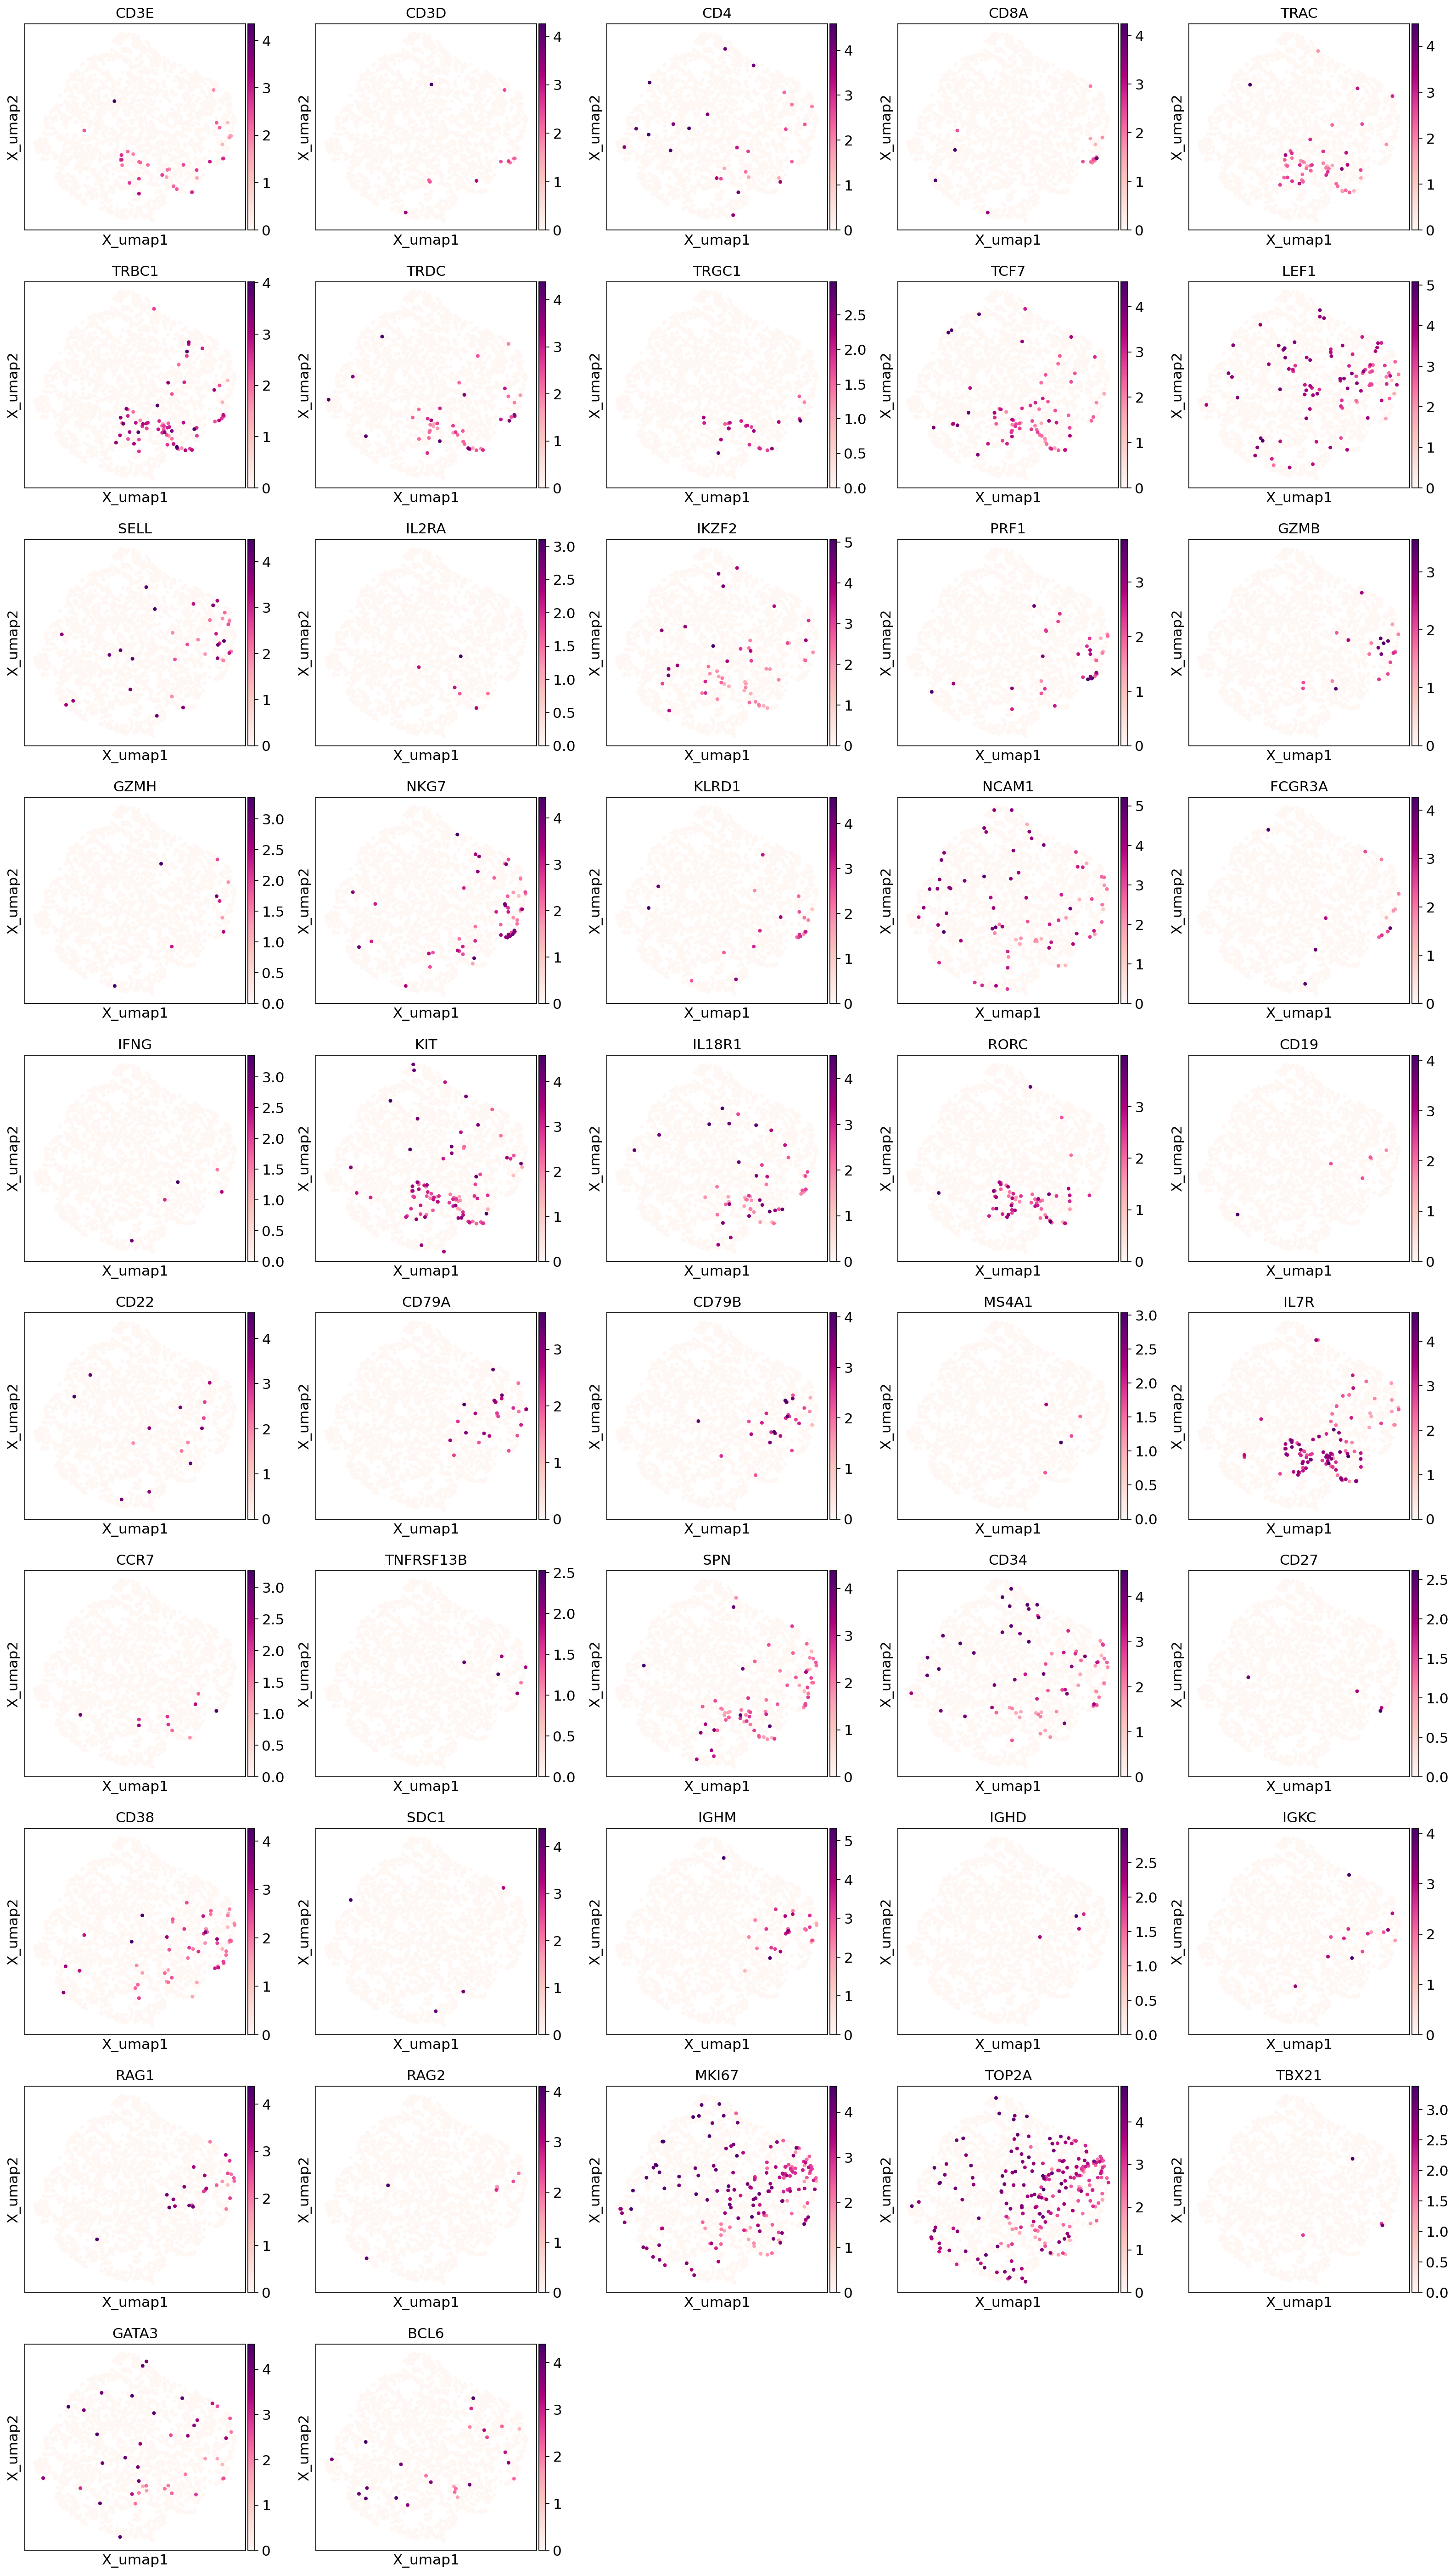

In [19]:
# markers for fine-grained cell types
markers={
     'T cell': ['CD3E', 'CD3D','CD4', 'CD8A', 'CD8B','TRAC','TRBC1','TRDC','TRGC1'],
    'naive': ['TCF7', 'LEF1', 'SELL'],
    'CD4T_reg': ['FOXP3', 'CTLA4', 'IL2RA', 'IKZF2'],
    'cytotoxic': ['PRF1', 'GZMB', 'GZMH', 'NKG7'],
    'NK': ['KLRF1', 'KLRD1', 'NCAM1','FCGR3A','IFNG'],
    'ILC3': ['KIT', 'IL18R1','RORC','IL17A'],
    
    'B': ['CD19','CD20','CD22','CD79A', 'CD79B','MS4A1','IL7R',],
    '':['CCR7','TNFRSF13B',],
    'ProB':['KIT','SPN','CD34'],
    'B1':['CD27','CCR10','MS4A1','SPN'],
    'Plasma': ['CD27','CCR10','CD38','SDC1','JCAIN'],
    'Abs':['IGHM','IGHD', 'IGHG1','IGHG2', 'IGHG3','IGHG4', 'IGHA1','IGHE','IGLC1','IGKC'],
    'Gene editing': ['AICDA', 'RAG1','RAG2'],
    
    
    'Cycling':['MKI67','TOP2A'],

    'TFs': ['TBX21', 'GATA3', 'RORC', 'BCL6',],
}

for key in markers.keys():
    markers[key]=[x for x in markers[key] if x in adata.var_names]

genes = []
for g in markers.values():
    genes = genes + [x for x in g if (x in adata.var_names)&(x not in genes)]
sc.pl.embedding(adata,basis='X_umap',color=genes,
               ncols=5, wspace=0.2,cmap='RdPu',vmax='p100')

In [20]:
resolution_sel = 0.5

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 12239 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: 0, 1, 2, etc.
var_group_labels: CM, Pcell, FB, etc.


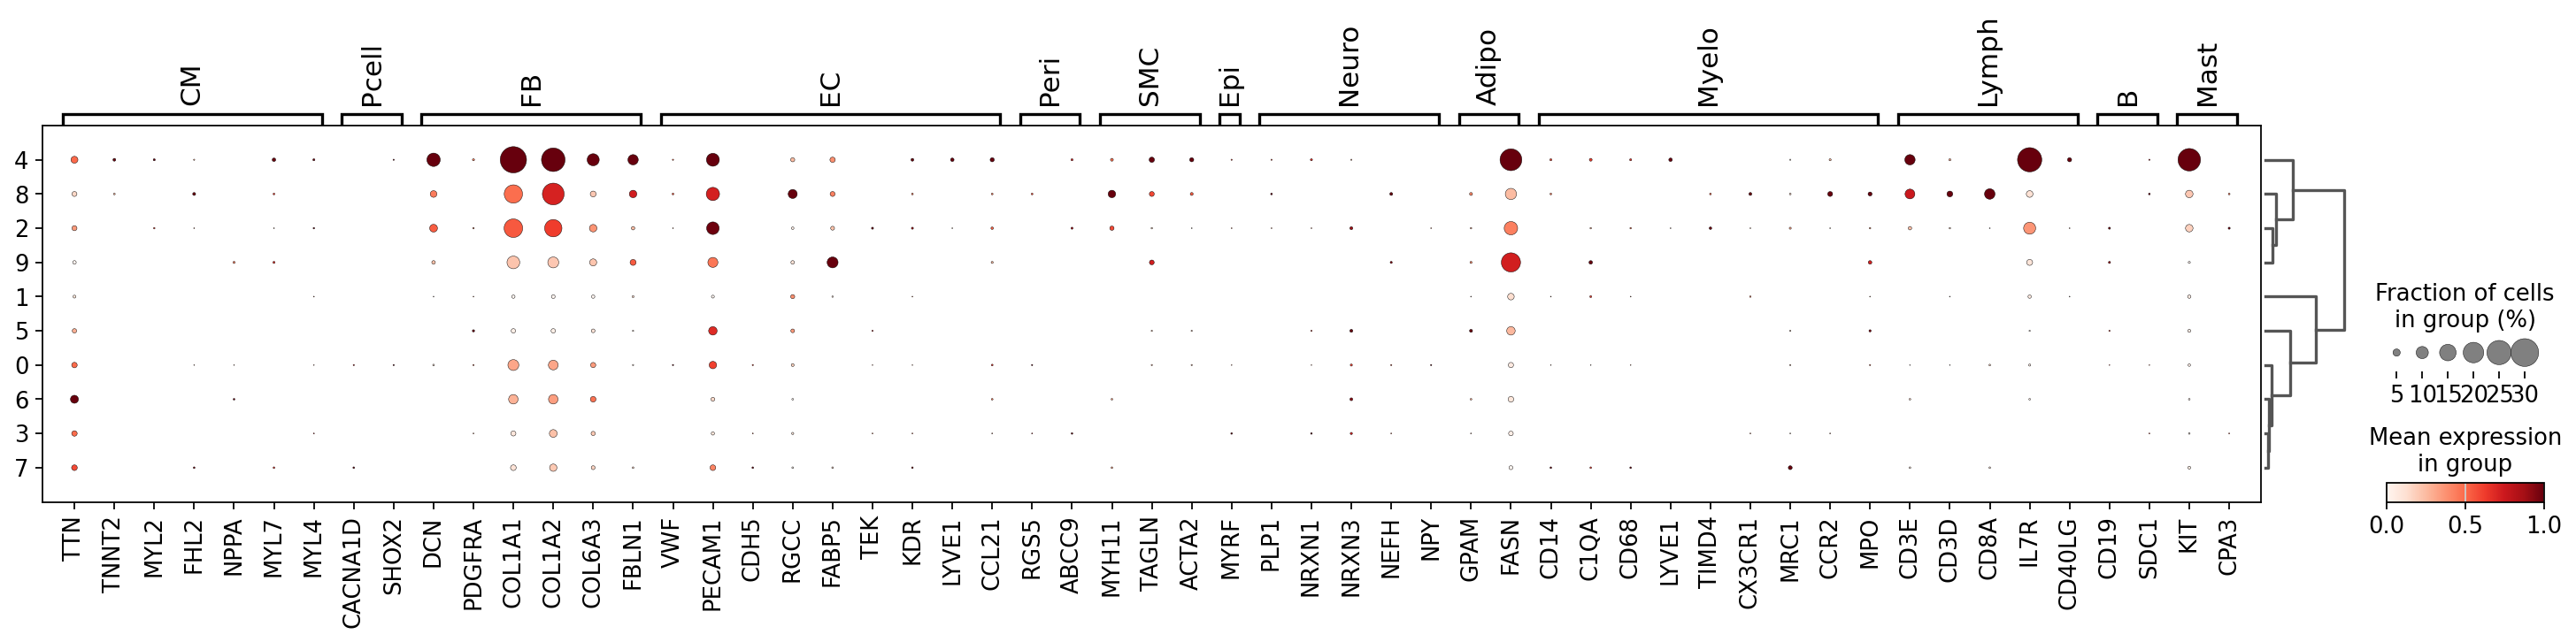

In [21]:
markers = {
    'CM': ['TTN', 'TNNT2','MYH6',
        'MYH7', 'MYL2', 'FHL2', # vCN
            'NPPA', 'MYL7', 'MYL4'], #aCM
    'Pcell':['HCN1','HCN4','CACNA1D','TBX3','SHOX2'],
    'FB': ['DCN', 'GCN', 'PDGFRA','COL1A1','COL1A2','COL6A3','FBLN1'],
    'EC': ['VWF', 'PECAM1', 'CDH5','RGCC', 'FABP5','TEK','KDR','LYVE1','CCL21'],
    'Peri': ['RGS5', 'ABCC9', 'KCNJ8'],
    'SMC': ['MYH11', 'TAGLN', 'ACTA2'],
    'Epi':['BNC1','MYRF','ITLN1','UPK3B','MSLN','WT1'],
    'Neuro': ['PLP1', 'NRXN1', 'NRXN3','PRPH', 'NEFL', 'NEFM', 'NEFH', 'STMN2', 'SST', 'SLC10A4', 'SLC18A3', 'TH', 'NPY'],
    'Adipo': ['GPAM', 'FASN', 'LEP'],
    'Myelo': ['CD14', 'C1QA', 'CD68','LYVE1','TIMD4','CX3CR1','TREM2','MRC1','CCR2','MPO'],
    'Lymph': ['CD3E','CD3D','CD8A','IL7R', 'CD40LG'],
    'B': ['CD19','SDC1','IGHG1','IGHA1'],
    'Mast': ['KIT', 'CPA3'],
}

for key in markers.keys():
    markers[key]=[x for x in markers[key] if x in adata.var_names]

sc.tl.dendrogram(adata, groupby=f'scVI_leiden_{str(resolution_sel)}')
sc.pl.dotplot(adata,
              markers, 
              groupby=f'scVI_leiden_{str(resolution_sel)}',
              dendrogram=True,
              standard_scale="var",
              color_map="Reds",
              swap_axes=False,
             )

categories: 0, 1, 2, etc.
var_group_labels: T cell, naive, CD4T_reg, etc.


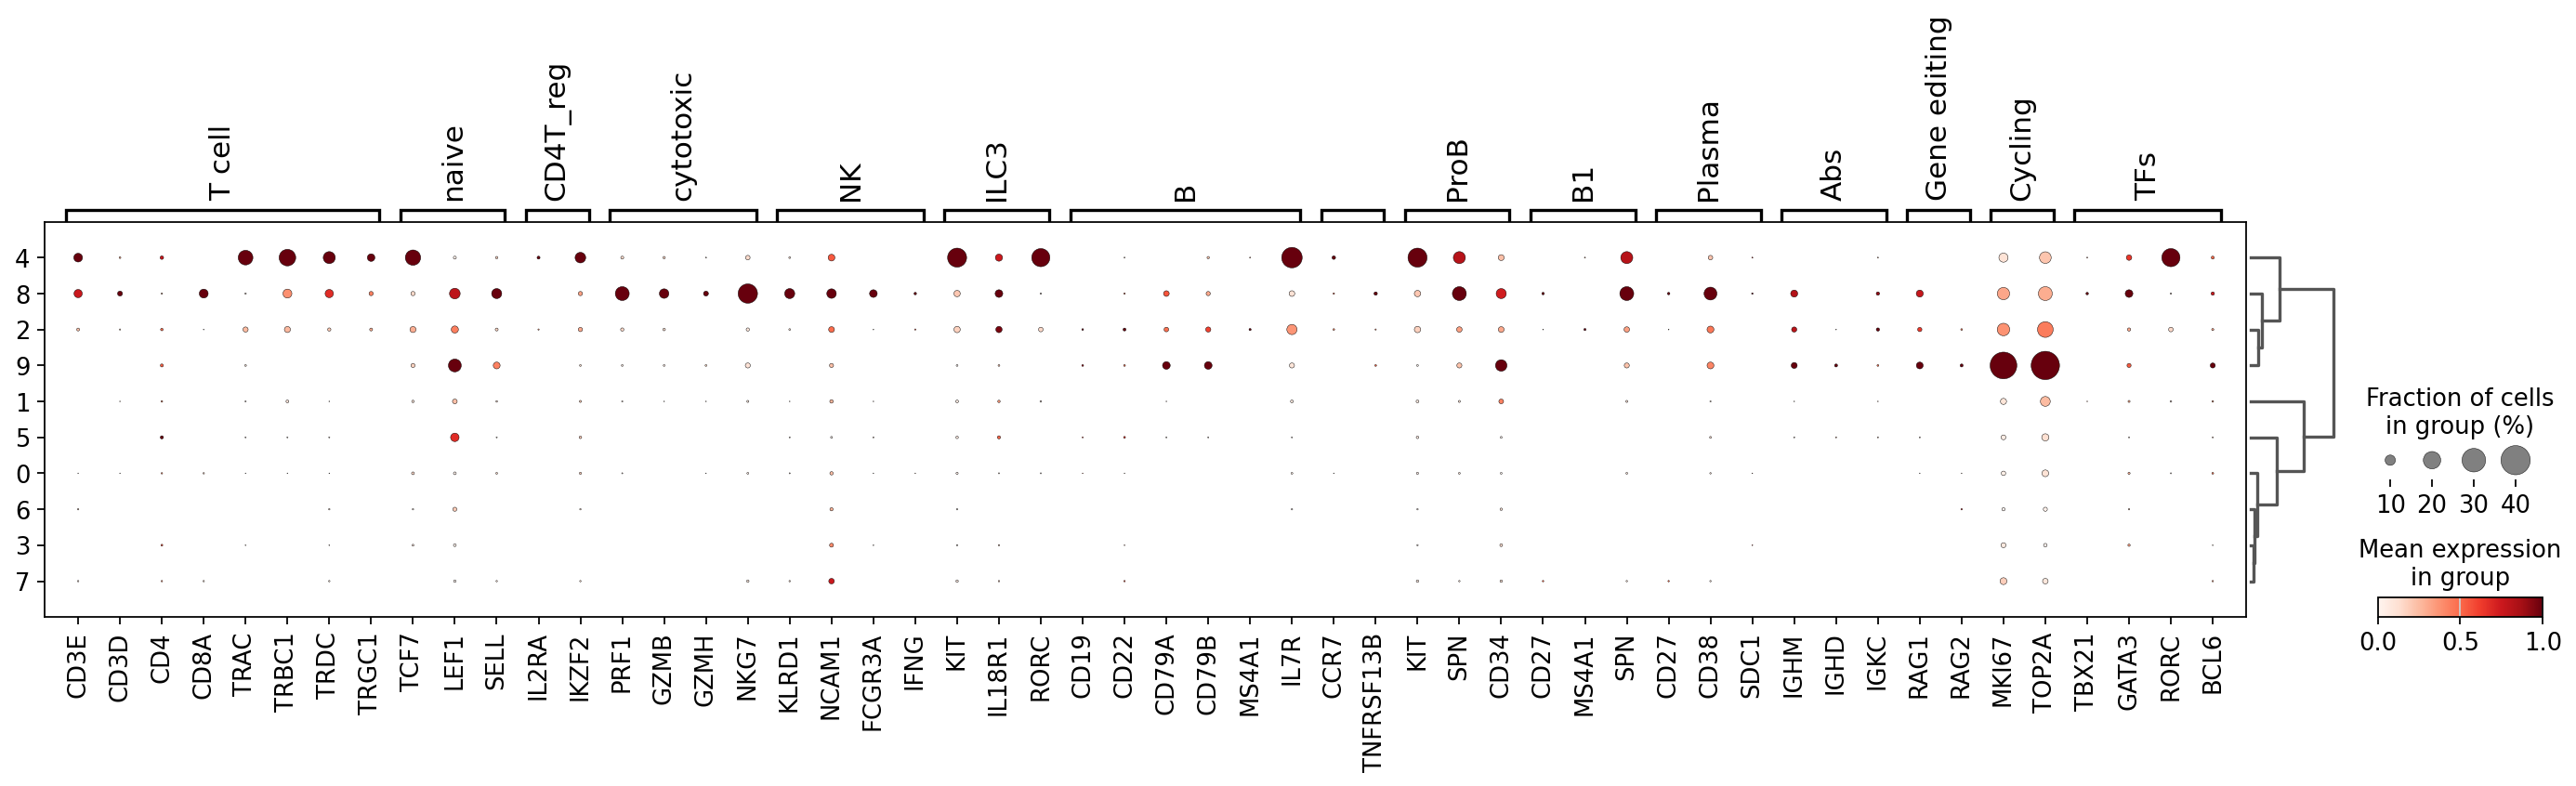

In [23]:
# markers for fine-grained cell types
markers={
     'T cell': ['CD3E', 'CD3D','CD4', 'CD8A', 'CD8B','TRAC','TRBC1','TRDC','TRGC1'],
    'naive': ['TCF7', 'LEF1', 'SELL'],
    'CD4T_reg': ['FOXP3', 'CTLA4', 'IL2RA', 'IKZF2'],
    'cytotoxic': ['PRF1', 'GZMB', 'GZMH', 'NKG7'],
    'NK': ['KLRF1', 'KLRD1', 'NCAM1','FCGR3A','IFNG'],
    'ILC3': ['KIT', 'IL18R1','RORC','IL17A'],
    
    'B': ['CD19','CD20','CD22','CD79A', 'CD79B','MS4A1','IL7R',],
    '':['CCR7','TNFRSF13B',],
    'ProB':['KIT','SPN','CD34'],
    'B1':['CD27','CCR10','MS4A1','SPN'],
    'Plasma': ['CD27','CCR10','CD38','SDC1','JCAIN'],
    'Abs':['IGHM','IGHD', 'IGHG1','IGHG2', 'IGHG3','IGHG4', 'IGHA1','IGHE','IGLC1','IGKC'],
    'Gene editing': ['AICDA', 'RAG1','RAG2'],
    
    
    'Cycling':['MKI67','TOP2A'],

    'TFs': ['TBX21', 'GATA3', 'RORC', 'BCL6',],
}

for key in markers.keys():
    markers[key]=[x for x in markers[key] if x in adata.var_names]

# sc.tl.dendrogram(adata,groupby=f'leiden_{str(resolution_sel)}')
sc.pl.dotplot(adata,
              var_names=markers,
              groupby=f'scVI_leiden_{str(resolution_sel)}',
              standard_scale='var',
              dendrogram=True
             )

[2.02537432 2.02537432 2.02537432 2.02537432 2.02537432]


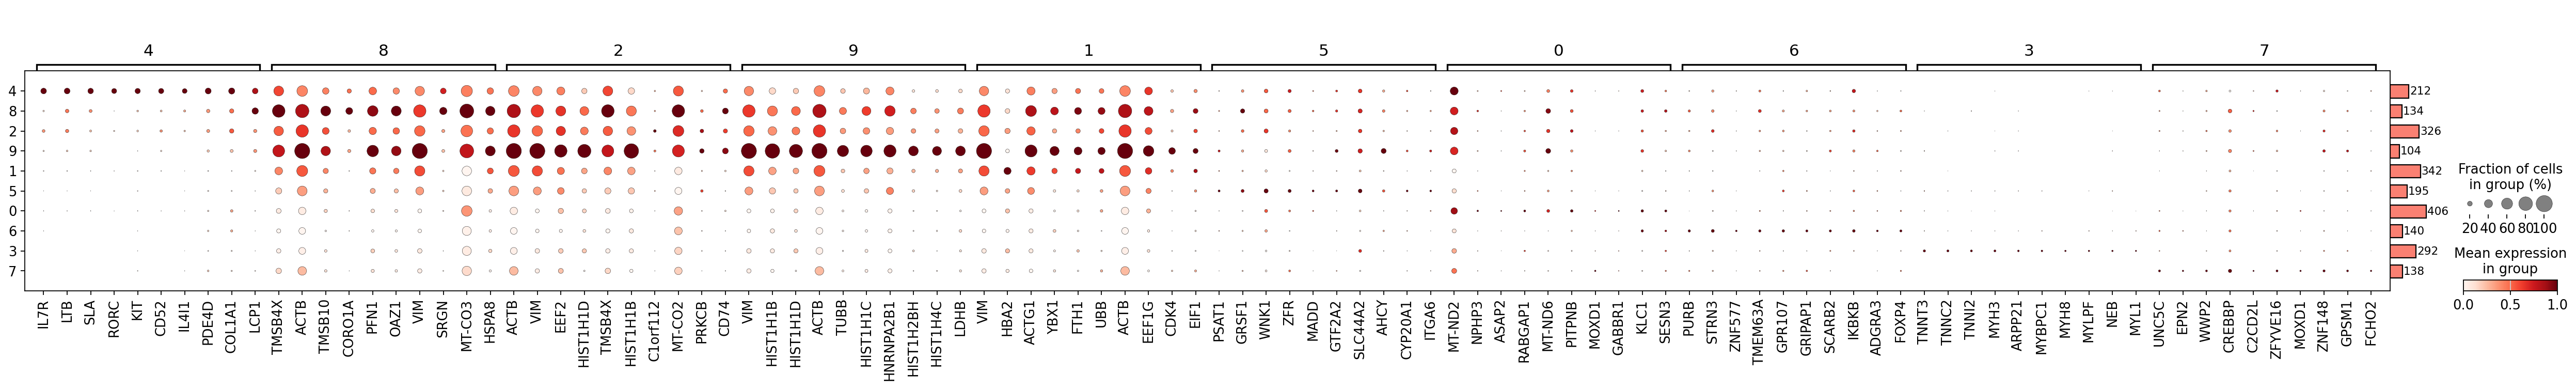

In [24]:
# DEG analysis
print(adata.X.data[:5])
adata.uns['log1p']['base']=None
sc.tl.rank_genes_groups(adata,groupby=f'scVI_leiden_{str(resolution_sel)}')
sc.tl.dendrogram(adata, groupby=f'scVI_leiden_{str(resolution_sel)}')
dp=sc.pl.rank_genes_groups_dotplot(adata, dendrogram=True, standard_scale='var', return_fig=True)
dp.add_totals().show()

# Total counts per group

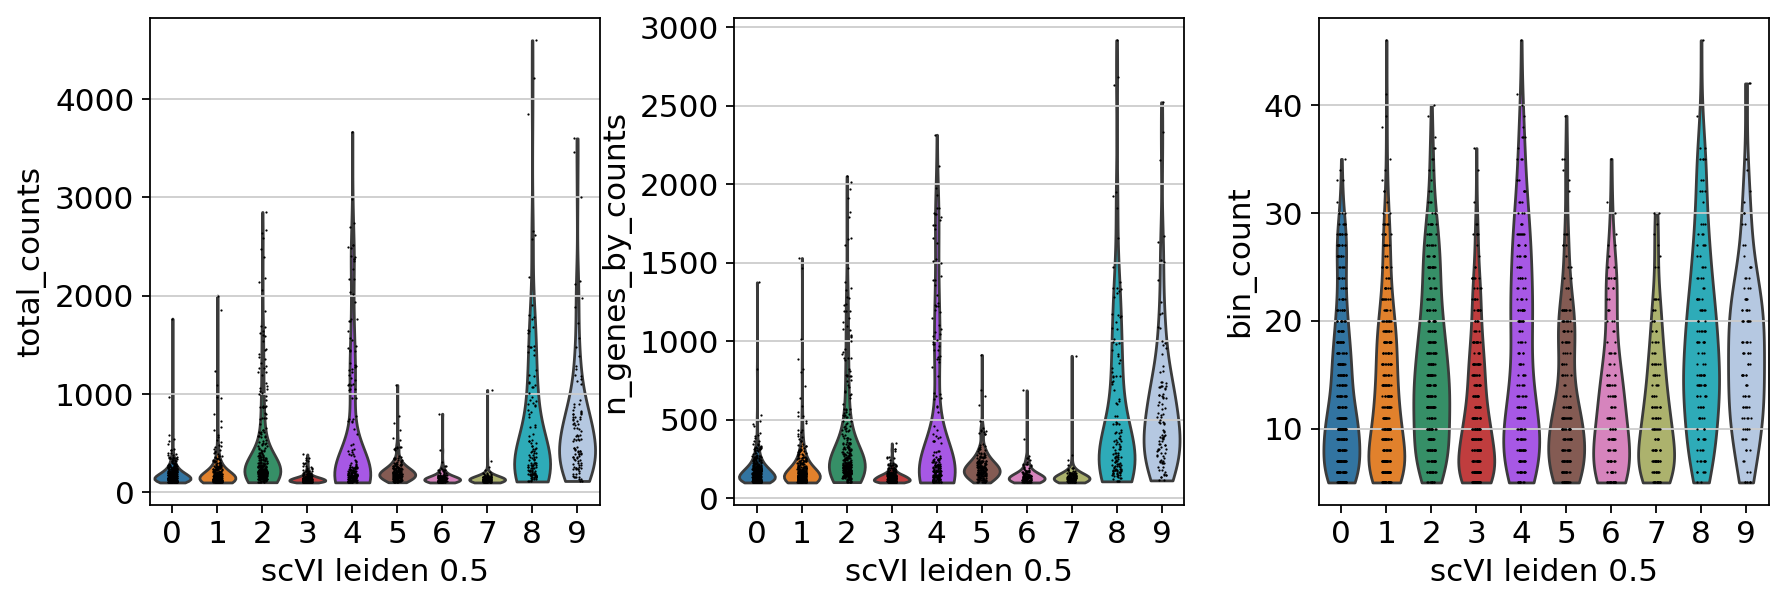

In [25]:
sc.pl.violin(adata,keys=['total_counts','n_genes_by_counts',
                         'bin_count'],groupby=f'scVI_leiden_{str(resolution_sel)}')

# Annotate

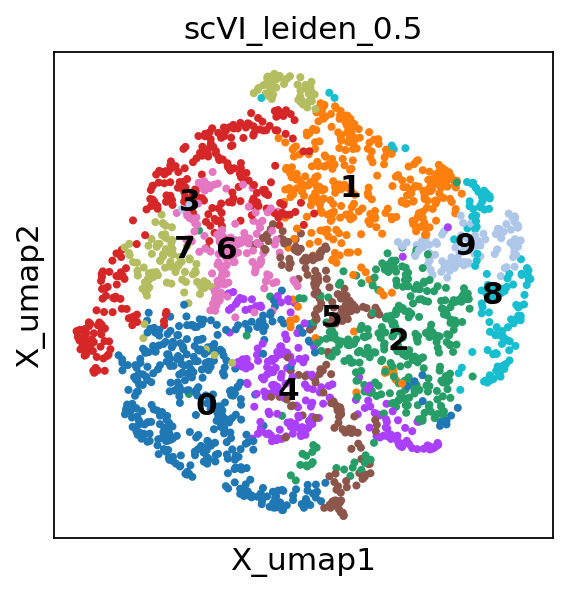

In [26]:
sc.pl.embedding(adata,basis='X_umap',
                color=f'scVI_leiden_{str(resolution_sel)}',
                wspace=0.3, legend_loc='on data')

In [27]:
# annotate
adata.obs['fine_grain'] = adata.obs[f'scVI_leiden_{str(resolution_sel)}'].copy()
adata.obs.replace({'fine_grain':{
    '0':'LowCounts',
    '1':'LowCounts',
    '2':'unclassified',
    '3':'LowCounts',
    '4':'InnateLymphoidCells',
    '5':'LowCounts',
    '6':'LowCounts',
    '7':'LowCounts',
    '8':'NaturalKillerCells',
    '9':'unclassified',
}},inplace=True)
adata.obs['fine_grain'].value_counts()

/tmp/ipykernel_2805508/2435777673.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({'fine_grain':{


fine_grain
LowCounts              1513
unclassified            430
InnateLymphoidCells     212
NaturalKillerCells      134
Name: count, dtype: int64

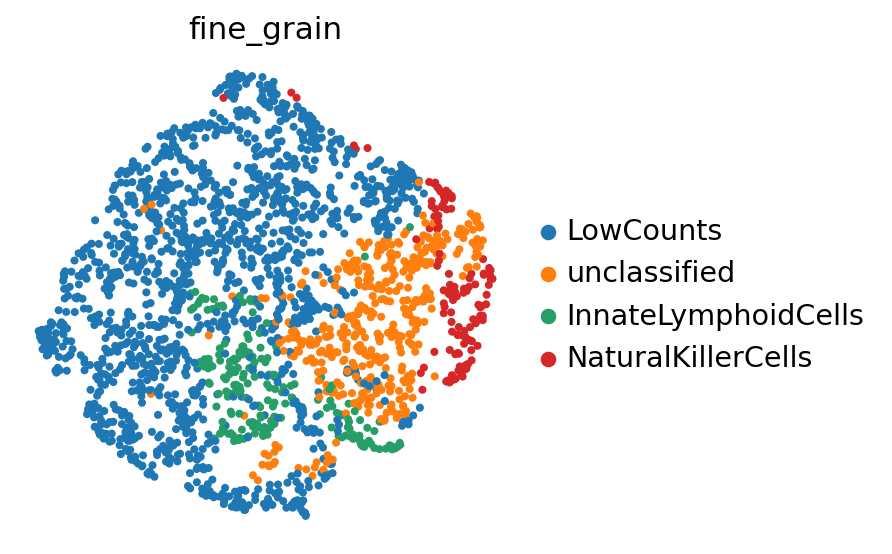

In [28]:
sc.pl.embedding(adata,basis='X_umap',
                color='fine_grain',
                frameon=False,
                wspace=0.3)

categories: LowCounts, unclassified, InnateLymphoidCells, etc.
var_group_labels: T cell, naive, CD4T_reg, etc.


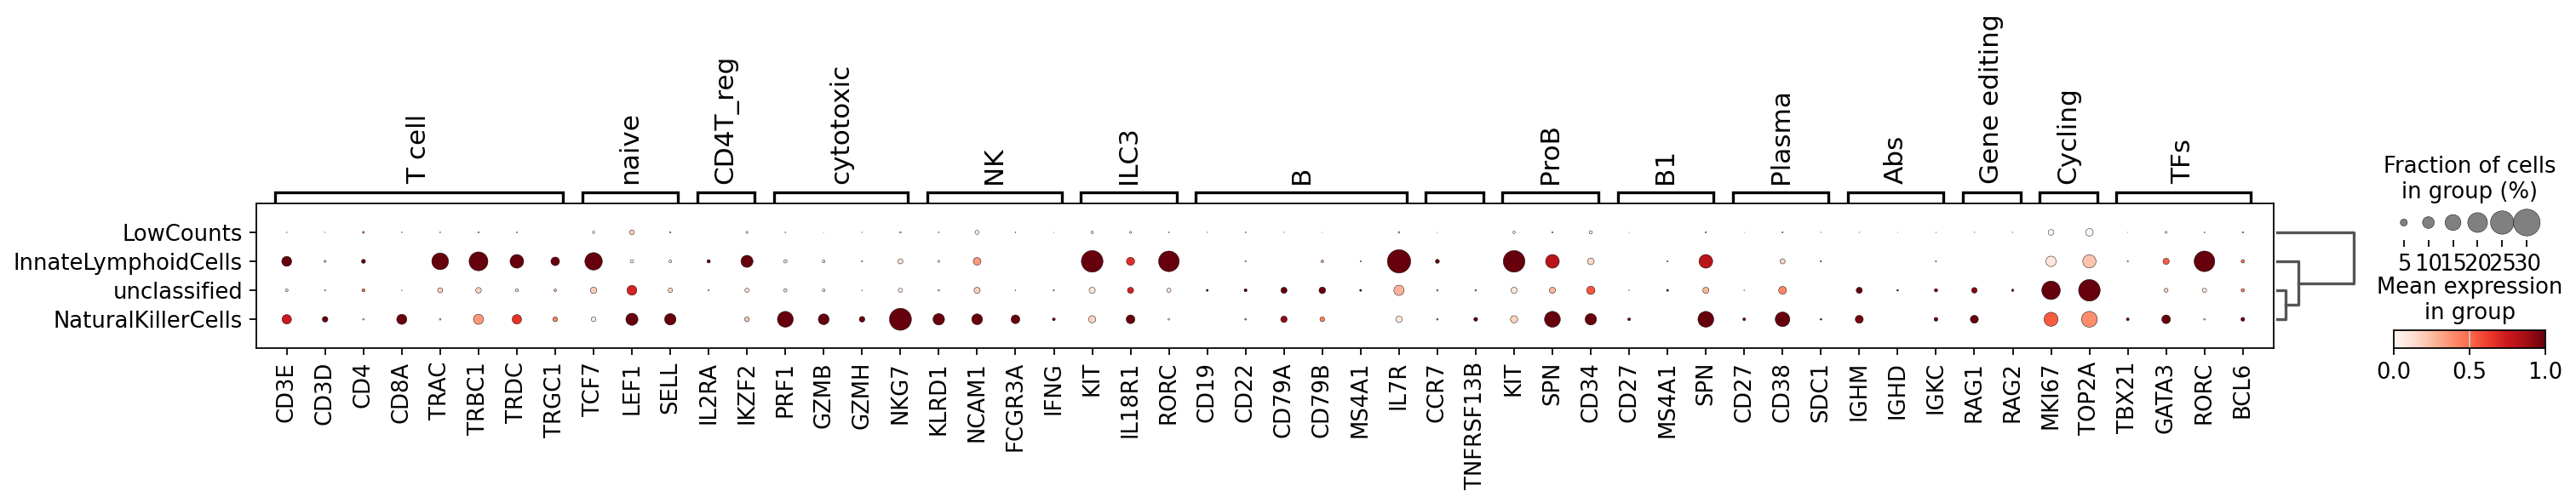

In [29]:
sc.tl.dendrogram(adata,groupby='fine_grain')
sc.pl.dotplot(adata,
              var_names=markers,
              groupby='fine_grain',
              standard_scale='var',
              dendrogram=True
             )

In [30]:
pd.crosstab(adata.obs['donor'],adata.obs['fine_grain']).T

donor,BRC2757,BRC2758,C194
fine_grain,,,
LowCounts,853,368,292
unclassified,227,109,94
InnateLymphoidCells,101,50,61
NaturalKillerCells,50,45,39


# Save

In [31]:
adata.write(f'{data_object_dir}/b2c_cells_{celltype}_lognorm.h5ad')
print(adata.X.data[:5])

[2.02537432 2.02537432 2.02537432 2.02537432 2.02537432]


In [32]:
data_object_dir

'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'